In [1]:
from backtest_functions import *

returns = get_backtest_data()
returns.head()

[*********************100%***********************]  3 of 3 completed


Ticker,BND,SPY,TSLA
Date,,,
2023-01-04,0.005677,0.007720,0.051249
2023-01-05,-0.001101,-0.011413,-0.029039
2023-01-06,0.011026,0.022932,0.024651
2023-01-09,0.002727,-0.000567,0.059349
2023-01-10,-0.003943,0.007013,-0.007681


In [2]:
strategy_weights = {
    "TSLA": 0.34736,
    "BND": 0.22089,
    "SPY": 0.43175
}

In [3]:
benchmark_weights = {
    "TSLA": 0.0,
    "BND": 0.40,
    "SPY": 0.60
}

In [4]:
strategy_returns = portfolio_returns(returns, strategy_weights)
benchmark_returns = portfolio_returns(returns, benchmark_weights)

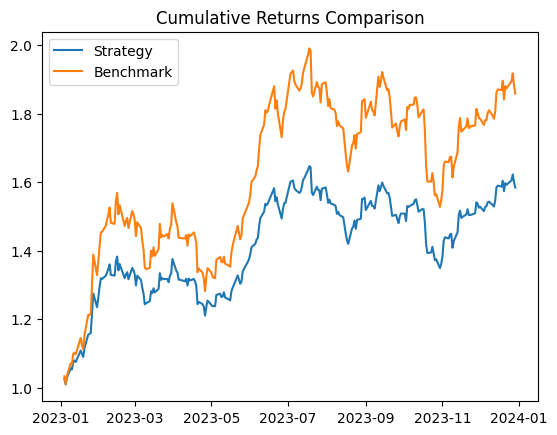

In [5]:
import matplotlib.pyplot as plt

cum_strategy = (1 + strategy_returns).cumprod()
cum_benchmark = (1 + benchmark_returns).cumprod()

plt.figure()
plt.plot(cum_strategy, label="Strategy")
plt.plot(cum_benchmark, label="Benchmark")
plt.legend()
plt.title("Cumulative Returns Comparison")
plt.savefig("outputs/cumulative_returns.png")
plt.show()

In [6]:
s_metrics = performance_metrics(strategy_returns)
b_metrics = performance_metrics(benchmark_returns)

import pandas as pd

metrics = pd.DataFrame({
    "Portfolio": ["Strategy", "Benchmark"],
    "Total Return": [s_metrics[0], b_metrics[0]],
    "Annual Return": [s_metrics[1], b_metrics[1]],
    "Sharpe Ratio": [s_metrics[2], b_metrics[2]],
    "Max Drawdown": [s_metrics[3], b_metrics[3]]
})

metrics.to_csv("outputs/performance_metrics.csv", index=False)
metrics


,Portfolio,Total Return,Annual Return,Sharpe Ratio,Max Drawdown
0,Strategy,0.584253,0.593060,1.998384,0.190172
1,Benchmark,0.858447,0.872376,1.979681,0.247655
